In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kazanova/sentiment140")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sentiment140' dataset.
Path to dataset files: /kaggle/input/sentiment140


In [ ]:
# Cell 0: Check what's inside the dataset folder
import os

dataset_path = "/kaggle/input/sentiment140"
print("Files in dataset folder:")
for f in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, f)
    size_mb = os.path.getsize(full_path) / (1024 * 1024)
    print(f"  {f}  →  {size_mb:.2f} MB")

Files in dataset folder:
  training.1600000.processed.noemoticon.csv  →  227.74 MB


In [ ]:
# Cell 1 (FIXED): Install Java 17 (pre-installed in Colab) + PySpark
!apt-get update -qq
!apt-get install -y openjdk-17-jdk-headless -qq > /dev/null
!pip install -q pyspark==3.5.0 findspark

# Verify Java installation
!java -version

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


In [ ]:
# Cell 2 (FIXED): Set JAVA_HOME to Java 17 and init Spark
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, lower, regexp_replace, length, when, explode, split
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

spark = SparkSession.builder \
    .appName("TwitterSentimentAnalysis") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

print("✅ Spark Version:", spark.version)
print("✅ Java Version:", spark.sparkContext._jvm.System.getProperty("java.version"))

✅ Spark Version: 3.5.0
✅ Java Version: 17.0.20.1


In [ ]:
# Cell 3: Read the CSV (no header, 6 columns)
csv_path = "/kaggle/input/sentiment140/training.1600000.processed.noemoticon.csv"

df = spark.read.csv(csv_path, header=False, inferSchema=True)
df = df.toDF("target", "id", "date", "flag", "user", "text")

print("✅ Total records:", df.count())
df.show(5, truncate=60)

✅ Total records: 1600000
+------+----------+----------------------------+--------+---------------+------------------------------------------------------------+
|target|        id|                        date|    flag|           user|                                                        text|
+------+----------+----------------------------+--------+---------------+------------------------------------------------------------+
|     0|1467810369|Mon Apr 06 22:19:45 PDT 2009|NO_QUERY|_TheSpecialOne_|@switchfoot http://twitpic.com/2y1zl - Awww, that's a bum...|
|     0|1467810672|Mon Apr 06 22:19:49 PDT 2009|NO_QUERY|  scotthamilton|is upset that he can't update his Facebook by texting it....|
|     0|1467810917|Mon Apr 06 22:19:53 PDT 2009|NO_QUERY|       mattycus|@Kenichan I dived many times for the ball. Managed to sav...|
|     0|1467811184|Mon Apr 06 22:19:57 PDT 2009|NO_QUERY|        ElleCTF|             my whole body feels itchy and like its on fire |
|     0|1467811193|Mon Apr 06 

In [ ]:
# Cell 4: Clean text + create binary label
df_clean = df.select("target", "text") \
    .withColumn("label", when(col("target") == 4, 1).otherwise(0)) \
    .drop("target") \
    .withColumn("text", lower(col("text"))) \
    .withColumn("text", regexp_replace("text", r"http\S+", "")) \
    .withColumn("text", regexp_replace("text", r"@\w+", "")) \
    .withColumn("text", regexp_replace("text", r"[^a-zA-Z\s]", "")) \
    .withColumn("text", regexp_replace("text", r"\s+", " ")) \
    .filter(length("text") > 3)

print("✅ Cleaned records:", df_clean.count())
df_clean.show(5, truncate=60)

# Check class balance
print("\n📊 Class distribution:")
df_clean.groupBy("label").count().show()

✅ Cleaned records: 1596239
+------------------------------------------------------------+-----+
|                                                        text|label|
+------------------------------------------------------------+-----+
| awww thats a bummer you shoulda got david carr of third ...|    0|
|is upset that he cant update his facebook by texting it a...|    0|
| i dived many times for the ball managed to save the rest...|    0|
|             my whole body feels itchy and like its on fire |    0|
| no its not behaving at all im mad why am i here because ...|    0|
+------------------------------------------------------------+-----+
only showing top 5 rows


📊 Class distribution:
+-----+------+
|label| count|
+-----+------+
|    1|797950|
|    0|798289|
+-----+------+



In [ ]:
# Cell 5: Split 80/20
train, test = df_clean.randomSplit([0.8, 0.2], seed=42)
print("✅ Train:", train.count(), "| Test:", test.count())

✅ Train: 1277460 | Test: 318779


In [ ]:
# Cell 6: Define pipeline
tokenizer = Tokenizer(inputCol="text", outputCol="words")
remover = StopWordsRemover(inputCol="words", outputCol="filtered")
hashingTF = HashingTF(inputCol="filtered", outputCol="rawFeatures", numFeatures=10000)
idf = IDF(inputCol="rawFeatures", outputCol="features")
lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=20)

pipeline = Pipeline(stages=[tokenizer, remover, hashingTF, idf, lr])

print("⏳ Training model (may take 2–4 min)...")
model = pipeline.fit(train)
print("✅ Model trained!")

⏳ Training model (may take 2–4 min)...
✅ Model trained!


In [ ]:
# Cell 7: Predict on test set
predictions = model.transform(test)
predictions.select("text", "label", "prediction").show(5, truncate=50)

+--------------------------------------------------+-----+----------+
|                                              text|label|prediction|
+--------------------------------------------------+-----+----------+
|                                           a baby |    0|       1.0|
|                     a bach party why you in abita|    0|       1.0|
|                                 a bad one i know |    0|       0.0|
|                      a banana hey i hate bananas |    0|       0.0|
| a beautiful book on whitehead was gifted to me...|    0|       1.0|
+--------------------------------------------------+-----+----------+
only showing top 5 rows



In [ ]:
# Cell 8: Accuracy + AUC
acc_eval = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="accuracy")
auc_eval = BinaryClassificationEvaluator(
    labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

accuracy = acc_eval.evaluate(predictions)
auc = auc_eval.evaluate(predictions)

print(f"✅ Accuracy: {accuracy:.4f}")
print(f"✅ AUC:      {auc:.4f}")

✅ Accuracy: 0.7615
✅ AUC:      0.8352


In [ ]:
# Cell 9: Confusion matrix counts
print("📊 Confusion Matrix (label vs prediction):")
predictions.groupBy("label", "prediction").count().orderBy("label", "prediction").show()

📊 Confusion Matrix (label vs prediction):
+-----+----------+------+
|label|prediction| count|
+-----+----------+------+
|    0|       0.0|118084|
|    0|       1.0| 41329|
|    1|       0.0| 34708|
|    1|       1.0|124658|
+-----+----------+------+



In [ ]:
# Cell 10: Top 15 words per sentiment
words_pos = df_clean.filter(col("label") == 1) \
    .select(explode(split(col("text"), " ")).alias("word")) \
    .filter(length("word") > 2) \
    .groupBy("word").count().orderBy(col("count").desc()).limit(15)

words_neg = df_clean.filter(col("label") == 0) \
    .select(explode(split(col("text"), " ")).alias("word")) \
    .filter(length("word") > 2) \
    .groupBy("word").count().orderBy(col("count").desc()).limit(15)

print("🔵 Top Positive Words:")
words_pos.show()
print("🔴 Top Negative Words:")
words_neg.show()

🔵 Top Positive Words:
+----+------+
|word| count|
+----+------+
| the|263867|
| you|176065|
| and|147272|
| for|117026|
|that| 68759|
|with| 64951|
|have| 62059|
|just| 61882|
|good| 60869|
| its| 49760|
|love| 46857|
| but| 46213|
| day| 45336|
| was| 45092|
|your| 44249|
+----+------+

🔴 Top Negative Words:
+----+------+
|word| count|
+----+------+
| the|256226|
| and|151193|
| for| 98698|
| you| 94093|
|have| 82491|
| but| 81308|
| not| 73533|
|that| 72596|
|just| 63188|
| was| 58997|
| its| 58834|
|this| 52113|
| now| 50662|
|with| 49930|
| get| 45379|
+----+------+



In [ ]:
# Cell 11: Install wordcloud (only once)
!pip install -q wordcloud

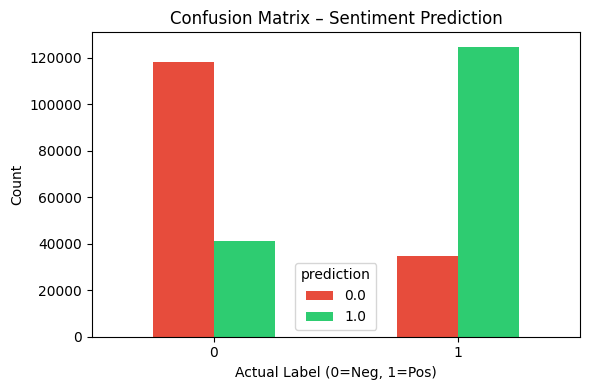

In [ ]:
# Cell 12: Generate all charts
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# ---- 12.1 Confusion Matrix Bar Chart ----
cm = predictions.groupBy("label", "prediction").count().toPandas()
cm_pivot = cm.pivot(index="label", columns="prediction", values="count").fillna(0)

cm_pivot.plot(kind="bar", figsize=(6,4), color=["#e74c3c", "#2ecc71"])
plt.title("Confusion Matrix – Sentiment Prediction")
plt.xlabel("Actual Label (0=Neg, 1=Pos)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

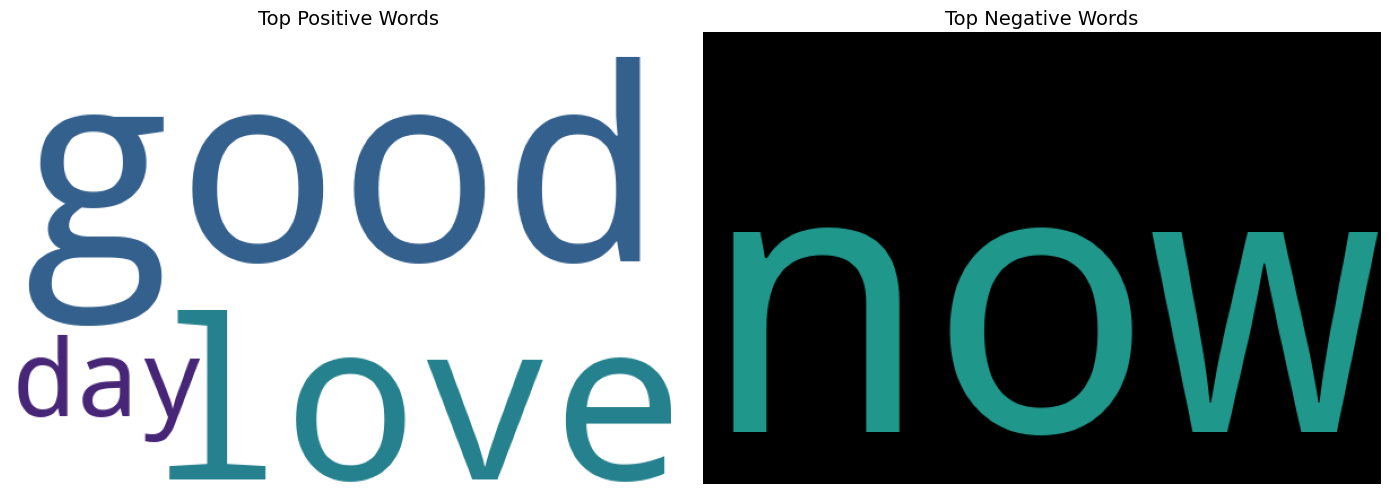

In [ ]:
# Cell 13: Word Clouds
pos_words = [r["word"] for r in words_pos.collect()]
neg_words = [r["word"] for r in words_neg.collect()]

pos_text = " ".join(pos_words)
neg_text = " ".join(neg_words)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].imshow(WordCloud(width=600, height=400, background_color="white").generate(pos_text))
axes[0].set_title("Top Positive Words", fontsize=14)
axes[0].axis("off")

axes[1].imshow(WordCloud(width=600, height=400, background_color="black").generate(neg_text))
axes[1].set_title("Top Negative Words", fontsize=14)
axes[1].axis("off")

plt.tight_layout()
plt.savefig("wordclouds.png", dpi=150)
plt.show()

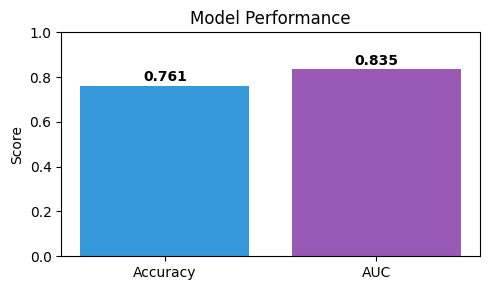

In [ ]:
# Cell 14: Model Performance Bar Chart
plt.figure(figsize=(5,3))
plt.bar(["Accuracy", "AUC"], [accuracy, auc], color=["#3498db", "#9b59b6"])
plt.ylim(0, 1)
plt.title("Model Performance")
plt.ylabel("Score")
for i, v in enumerate([accuracy, auc]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("performance.png", dpi=150)
plt.show()

In [ ]:
# Cell 15: Download all images
from google.colab import files
files.download("confusion_matrix.png")
files.download("wordclouds.png")
files.download("performance.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>